2025-03-28 00:14:54,972 - INFO - Loading spectral data...
2025-03-28 00:14:54,974 - INFO - Processing RGB data...
2025-03-28 00:14:54,975 - INFO - Normalizing RGB data...
2025-03-28 00:14:54,975 - INFO - Iteration 1/4 - Training the model...
2025-03-28 00:14:54,985 - INFO - Epoch 1/500 - Training Loss: 21.1889 - Validation Loss: 0.4819
2025-03-28 00:14:54,993 - INFO - Epoch 2/500 - Training Loss: 6.7913 - Validation Loss: 0.1874
2025-03-28 00:14:55,000 - INFO - Epoch 3/500 - Training Loss: 3.4186 - Validation Loss: 0.1269
2025-03-28 00:14:55,008 - INFO - Epoch 4/500 - Training Loss: 2.3396 - Validation Loss: 0.0885
2025-03-28 00:14:55,020 - INFO - Epoch 5/500 - Training Loss: 1.6876 - Validation Loss: 0.0662
2025-03-28 00:14:55,028 - INFO - Epoch 6/500 - Training Loss: 1.2408 - Validation Loss: 0.0506
2025-03-28 00:14:55,035 - INFO - Epoch 7/500 - Training Loss: 0.9382 - Validation Loss: 0.0393
2025-03-28 00:14:55,043 - INFO - Epoch 8/500 - Training Loss: 0.7504 - Validation Loss: 0.03

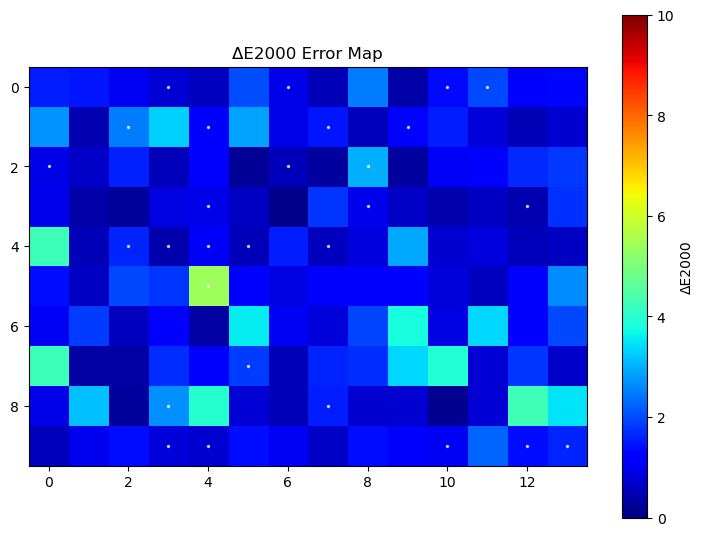

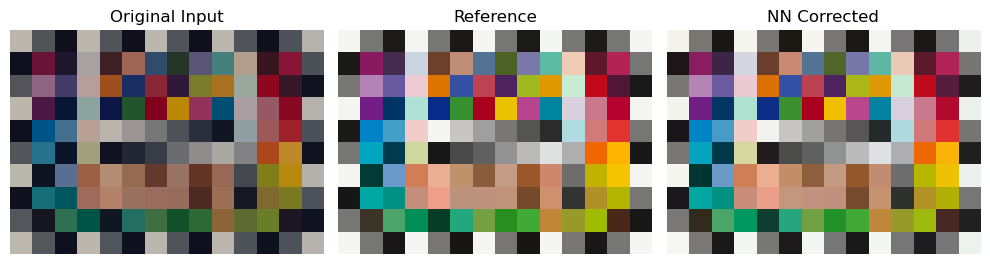

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import StandardScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt
import copy
import os

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a fixed seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions
###########################################
def process_rgb(cube, bands, ill, CMFs):
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)
    rgb = color.xyz2rgb(xyz)
    return rgb

###########################################
# 1. Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube_path = '../../data/colorChecker_SG/cubes/cubeCC_fuji-frame4.hdr'
cube = spectral.open_image(cube_path)
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()         
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# 2. Process RGB data
###########################################
logging.info('Processing RGB data...')
rgb_input = process_rgb(cube_data, wl_input, ill, CMFs)   
rgb_ref = process_rgb(cube_ref_data, wl_ref, ill, CMFs)   

###########################################
# 3. Normalize data in RGB space
###########################################
logging.info('Normalizing RGB data...')
X_flat = rgb_input.reshape(-1, 3)
Y_flat = rgb_ref.reshape(-1, 3)

scaler_input = StandardScaler()
scaler_ref = StandardScaler()

###########################################
# 4. Define MLP Model
###########################################
class SimpleMLP(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, output_size=3):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

# Training settings
num_iterations = 4  # Number of iterative refinement steps
epochs = 500
batch_size = 4
alpha = 0.6  # Blending factor for residual learning

for iteration in range(num_iterations):
    logging.info(f'Iteration {iteration + 1}/{num_iterations} - Training the model...')

    # Dynamically update normalization
    X_norm = scaler_input.fit_transform(X_flat)
    Y_norm = scaler_ref.fit_transform(Y_flat)

    X_train_torch = torch.tensor(X_norm, dtype=torch.float32)
    Y_train_torch = torch.tensor(Y_norm, dtype=torch.float32)
    np.random.seed(seed)
    
    # Split into train/test
    n_pixels = X_norm.shape[0]
    train_size = int(0.8 * n_pixels)
    train_indices = np.random.choice(n_pixels, train_size, replace=False)
    test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)

    X_train = X_train_torch[train_indices]
    Y_train = Y_train_torch[train_indices]
    X_test = X_train_torch[test_indices]
    Y_test = Y_train_torch[test_indices]

    # Initialize model
    model = SimpleMLP()
    optimizer = optim.Adam(model.parameters(), lr=0.001 / (iteration + 1), weight_decay=1e-5)  
    loss_function = nn.MSELoss()

    # Training loop
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        perm = torch.randperm(X_train.size(0))
        for i in range(0, X_train.size(0), batch_size):
            batch_indices = perm[i:i+batch_size]
            X_batch = X_train[batch_indices]
            Y_batch = Y_train[batch_indices]

            optimizer.zero_grad()
            Y_pred = model(X_batch)
            loss = loss_function(Y_pred, Y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Validation loss
        model.eval()
        with torch.no_grad():
            Y_val_pred = model(X_test)
            val_loss = loss_function(Y_val_pred, Y_test).item()
        
        logging.info(f'Epoch {epoch+1}/{epochs} - Training Loss: {epoch_loss:.4f} - Validation Loss: {val_loss:.4f}')

    # Apply correction
    model.eval()
    with torch.no_grad():
        corrected_flat = model(torch.tensor(X_norm, dtype=torch.float32)).numpy()

    # Residual learning: mix original with corrected
    X_flat = alpha * corrected_flat + (1 - alpha) * X_flat  

# Final correction
corrected_rgb = scaler_ref.inverse_transform(X_flat)
corrected_rgb_image = corrected_rgb.reshape(rgb_ref.shape)

###########################################
# 5. Compute ΔE2000 Error Maps
###########################################
logging.info('Computing ΔE2000 error map...')
corrected_lab = color.rgb2lab(corrected_rgb_image)
lab_ref = color.rgb2lab(rgb_ref)

# Compute ΔE2000 error
error_map = color.deltaE_ciede2000(lab_ref, corrected_lab)

# Compute mean & max error
error_map_flat = error_map.reshape(-1)
test_error_values = error_map_flat[test_indices]
mean_error_test = np.mean(test_error_values)
max_error_test = np.max(test_error_values)

logging.info(f"Mean ΔE2000 Error: {mean_error_test:.2f}")
logging.info(f"Max ΔE2000 Error: {max_error_test:.2f}")

# Get test pixel positions
test_positions = np.unravel_index(test_indices, lab_ref.shape[:2])

# Plot error map
plt.figure(figsize=(8, 6))
plt.imshow(error_map, cmap='jet', vmin=0, vmax=10)
plt.colorbar(label='ΔE2000')
plt.scatter(test_positions[1], test_positions[0], s=2, c='white', label='Test Patches', alpha=0.7)
plt.title('ΔE2000 Error Map')
plt.tight_layout(pad=3.0)
plt.show()

# Comparison plot
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(np.clip(rgb_input, 0, 1))
plt.title('Original Input')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(np.clip(rgb_ref, 0, 1))
plt.title('Reference')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(np.clip(corrected_rgb_image, 0, 1))
plt.title('NN Corrected')
plt.axis('off')
plt.tight_layout()
plt.show()


2025-03-28 00:10:36,624 - INFO - Loading spectral data...
2025-03-28 00:10:36,626 - INFO - Processing RGB data...
2025-03-28 00:10:36,627 - INFO - Normalizing RGB data...
2025-03-28 00:10:36,627 - INFO - Iteration 1/4
2025-03-28 00:10:36,637 - INFO - Epoch 1/500 - Train Loss: 21.1889 - Val Loss: 0.4819
2025-03-28 00:10:36,645 - INFO - Epoch 2/500 - Train Loss: 6.7913 - Val Loss: 0.1874
2025-03-28 00:10:36,653 - INFO - Epoch 3/500 - Train Loss: 3.4186 - Val Loss: 0.1269
2025-03-28 00:10:36,660 - INFO - Epoch 4/500 - Train Loss: 2.3396 - Val Loss: 0.0885
2025-03-28 00:10:36,667 - INFO - Epoch 5/500 - Train Loss: 1.6876 - Val Loss: 0.0662
2025-03-28 00:10:36,675 - INFO - Epoch 6/500 - Train Loss: 1.2408 - Val Loss: 0.0506
2025-03-28 00:10:36,683 - INFO - Epoch 7/500 - Train Loss: 0.9382 - Val Loss: 0.0393
2025-03-28 00:10:36,690 - INFO - Epoch 8/500 - Train Loss: 0.7504 - Val Loss: 0.0325
2025-03-28 00:10:36,697 - INFO - Epoch 9/500 - Train Loss: 0.6140 - Val Loss: 0.0289
2025-03-28 00:10

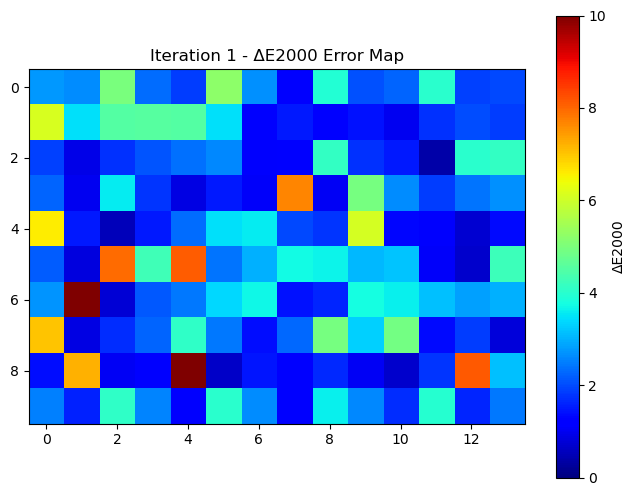

2025-03-28 00:10:38,515 - INFO - Iteration 2/4
2025-03-28 00:10:38,523 - INFO - Epoch 1/500 - Train Loss: 24.9330 - Val Loss: 0.5964
2025-03-28 00:10:38,531 - INFO - Epoch 2/500 - Train Loss: 13.8889 - Val Loss: 0.3476
2025-03-28 00:10:38,538 - INFO - Epoch 3/500 - Train Loss: 7.3094 - Val Loss: 0.2044
2025-03-28 00:10:38,546 - INFO - Epoch 4/500 - Train Loss: 3.9321 - Val Loss: 0.1261
2025-03-28 00:10:38,553 - INFO - Epoch 5/500 - Train Loss: 2.3549 - Val Loss: 0.0854
2025-03-28 00:10:38,561 - INFO - Epoch 6/500 - Train Loss: 1.5547 - Val Loss: 0.0582
2025-03-28 00:10:38,569 - INFO - Epoch 7/500 - Train Loss: 1.0821 - Val Loss: 0.0396
2025-03-28 00:10:38,576 - INFO - Epoch 8/500 - Train Loss: 0.7613 - Val Loss: 0.0283
2025-03-28 00:10:38,584 - INFO - Epoch 9/500 - Train Loss: 0.5672 - Val Loss: 0.0209
2025-03-28 00:10:38,591 - INFO - Epoch 10/500 - Train Loss: 0.4347 - Val Loss: 0.0165
2025-03-28 00:10:38,599 - INFO - Epoch 11/500 - Train Loss: 0.3548 - Val Loss: 0.0137
2025-03-28 00:

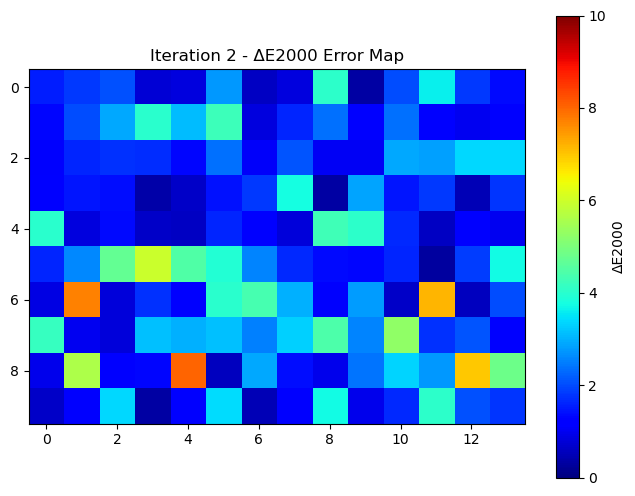

2025-03-28 00:10:39,379 - INFO - Iteration 3/4
2025-03-28 00:10:39,388 - INFO - Epoch 1/500 - Train Loss: 31.1066 - Val Loss: 0.8927
2025-03-28 00:10:39,396 - INFO - Epoch 2/500 - Train Loss: 21.8964 - Val Loss: 0.5997
2025-03-28 00:10:39,403 - INFO - Epoch 3/500 - Train Loss: 15.0742 - Val Loss: 0.3967
2025-03-28 00:10:39,411 - INFO - Epoch 4/500 - Train Loss: 10.4726 - Val Loss: 0.2521
2025-03-28 00:10:39,418 - INFO - Epoch 5/500 - Train Loss: 7.1875 - Val Loss: 0.1600
2025-03-28 00:10:39,426 - INFO - Epoch 6/500 - Train Loss: 5.0244 - Val Loss: 0.1049
2025-03-28 00:10:39,434 - INFO - Epoch 7/500 - Train Loss: 3.6303 - Val Loss: 0.0714
2025-03-28 00:10:39,441 - INFO - Epoch 8/500 - Train Loss: 2.7066 - Val Loss: 0.0518
2025-03-28 00:10:39,449 - INFO - Epoch 9/500 - Train Loss: 2.0791 - Val Loss: 0.0388
2025-03-28 00:10:39,456 - INFO - Epoch 10/500 - Train Loss: 1.6432 - Val Loss: 0.0302
2025-03-28 00:10:39,464 - INFO - Epoch 11/500 - Train Loss: 1.3118 - Val Loss: 0.0247
2025-03-28 0

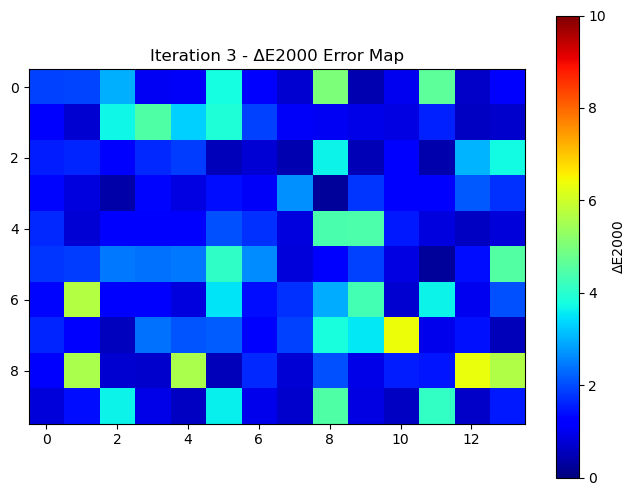

2025-03-28 00:10:42,119 - INFO - Iteration 4/4
2025-03-28 00:10:42,128 - INFO - Epoch 1/500 - Train Loss: 27.6002 - Val Loss: 0.8159
2025-03-28 00:10:42,136 - INFO - Epoch 2/500 - Train Loss: 20.6255 - Val Loss: 0.6112
2025-03-28 00:10:42,143 - INFO - Epoch 3/500 - Train Loss: 15.5464 - Val Loss: 0.4551
2025-03-28 00:10:42,151 - INFO - Epoch 4/500 - Train Loss: 11.6909 - Val Loss: 0.3336
2025-03-28 00:10:42,158 - INFO - Epoch 5/500 - Train Loss: 8.7535 - Val Loss: 0.2536
2025-03-28 00:10:42,166 - INFO - Epoch 6/500 - Train Loss: 6.6677 - Val Loss: 0.1935
2025-03-28 00:10:42,180 - INFO - Epoch 7/500 - Train Loss: 5.1700 - Val Loss: 0.1449
2025-03-28 00:10:42,188 - INFO - Epoch 8/500 - Train Loss: 4.0014 - Val Loss: 0.1145
2025-03-28 00:10:42,195 - INFO - Epoch 9/500 - Train Loss: 3.1565 - Val Loss: 0.0911
2025-03-28 00:10:42,203 - INFO - Epoch 10/500 - Train Loss: 2.5310 - Val Loss: 0.0730
2025-03-28 00:10:42,210 - INFO - Epoch 11/500 - Train Loss: 2.0426 - Val Loss: 0.0606
2025-03-28 0

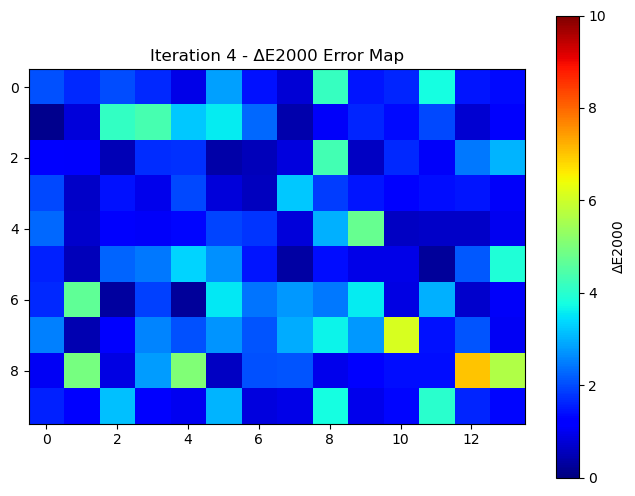

2025-03-28 00:10:43,684 - INFO - Final error evaluation:
2025-03-28 00:10:43,685 - INFO - Final Mean ΔE2000 Error: 1.73
2025-03-28 00:10:43,685 - INFO - Final Max ΔE2000 Error: 3.89


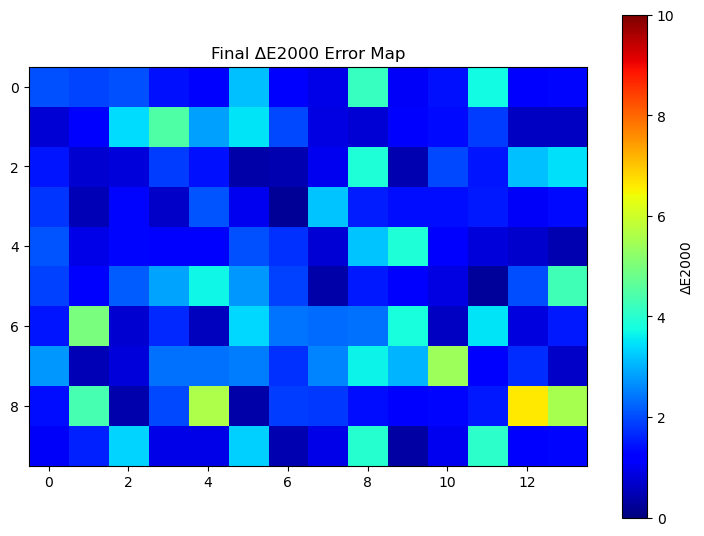

2025-03-28 00:10:43,780 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05895241422042519..0.9752702885423472].


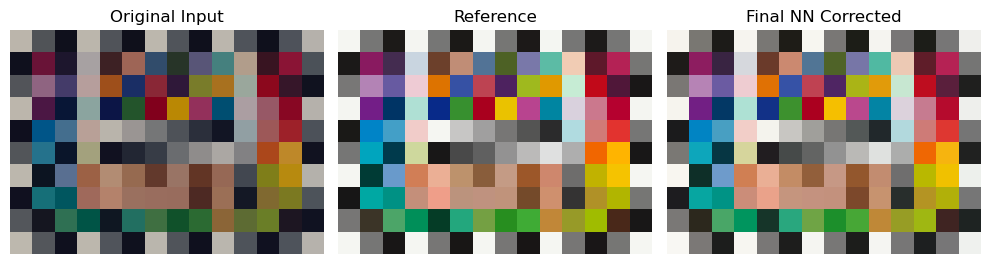

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import StandardScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt
import copy
import os

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a fixed seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions
###########################################
def process_rgb(cube, bands, ill, CMFs):
    """Converts hyperspectral cube data to RGB using XYZ conversion."""
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)
    rgb = color.xyz2rgb(xyz)
    return rgb

###########################################
# Early stopping class
###########################################
class EarlyStopping:
    """Stops training if validation loss doesn't improve after a set patience."""
    def __init__(self, patience=20, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):
        if val_loss + self.min_delta < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0  # Reset patience
        else:
            self.counter += 1  # Increment patience
        return self.counter >= self.patience  # Return True if no improvement

###########################################
# 1. Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube_path = '../../data/colorChecker_SG/cubes/cubeCC_fuji-frame4.hdr'
cube = spectral.open_image(cube_path)
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()         
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref   = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# 2. Process RGB data
###########################################
logging.info('Processing RGB data...')
rgb_input = process_rgb(cube_data, wl_input, ill, CMFs)   
rgb_ref   = process_rgb(cube_ref_data, wl_ref, ill, CMFs)   

H, W, C = rgb_input.shape

###########################################
# 3. Normalize data in RGB space
###########################################
logging.info('Normalizing RGB data...')
# Flatten the images so each pixel is a sample
X_flat = rgb_input.reshape(-1, 3)
Y_flat = rgb_ref.reshape(-1, 3)

scaler_input = StandardScaler()
scaler_ref = StandardScaler()

###########################################
# 4. Define the MLP model
###########################################
class SimpleMLP(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, output_size=3):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

###########################################
# 5. Iterative Training with Early Stopping and Residual Learning (Blending)
###########################################
iterations = 4       # Number of refinement steps
epochs = 500         # Maximum epochs per iteration
batch_size = 4
alpha = 0.6          # Blending factor for residual learning

for iter_num in range(iterations):
    logging.info(f"Iteration {iter_num + 1}/{iterations}")

    # Dynamically update normalization for current data
    X_norm = scaler_input.fit_transform(X_flat)
    Y_norm = scaler_ref.fit_transform(Y_flat)

    # Convert normalized data to torch tensors
    X_tensor = torch.tensor(X_norm, dtype=torch.float32)
    Y_tensor = torch.tensor(Y_norm, dtype=torch.float32)

    np.random.seed(seed)
    # Split into training (80%) and test (20%) sets
    n_pixels = X_norm.shape[0]
    train_size = int(0.8 * n_pixels)
    train_indices = np.random.choice(n_pixels, train_size, replace=False)
    test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)

    X_train = X_tensor[train_indices]
    Y_train = Y_tensor[train_indices]
    X_test = X_tensor[test_indices]
    Y_test = Y_tensor[test_indices]

    # Initialize model, optimizer, loss function, and early stopping
    model = SimpleMLP()
    optimizer = optim.Adam(model.parameters(), lr=0.001 / (iter_num + 1), weight_decay=1e-5)
    loss_function = nn.MSELoss()
    early_stopping = EarlyStopping(patience=50, min_delta=1e-5)

    # Training loop with early stopping
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        perm = torch.randperm(X_train.size(0))
        for i in range(0, X_train.size(0), batch_size):
            batch_indices = perm[i:i+batch_size]
            X_batch = X_train[batch_indices]
            Y_batch = Y_train[batch_indices]

            optimizer.zero_grad()
            Y_pred = model(X_batch)
            loss = loss_function(Y_pred, Y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Compute validation loss on test set
        model.eval()
        with torch.no_grad():
            Y_val_pred = model(X_test)
            val_loss = loss_function(Y_val_pred, Y_test).item()

        logging.info(f'Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f} - Val Loss: {val_loss:.4f}')
        if early_stopping(val_loss):
            logging.info(f"Early stopping triggered at epoch {epoch+1}")
            break

    # After training, apply correction using the current model (for visualization)
    model.eval()
    with torch.no_grad():
        corrected_norm = model(torch.tensor(X_norm, dtype=torch.float32)).numpy()
    corrected_rgb = scaler_ref.inverse_transform(corrected_norm)
    corrected_rgb_image = corrected_rgb.reshape(rgb_ref.shape)

    # Compute ΔE2000 error map for current iteration
    corrected_lab = color.rgb2lab(corrected_rgb_image)
    lab_ref_current = color.rgb2lab(rgb_ref)
    error_map = color.deltaE_ciede2000(lab_ref_current, corrected_lab)

    # Evaluate error on the test indices for this iteration
    error_map_flat = error_map.reshape(-1)
    mean_error = np.mean(error_map_flat[test_indices])
    max_error = np.max(error_map_flat[test_indices])
    logging.info(f"Iteration {iter_num+1}: Mean ΔE2000 Error: {mean_error:.2f}, Max ΔE2000 Error: {max_error:.2f}")

    # Plot error map for current iteration
    plt.figure(figsize=(8,6))
    plt.imshow(error_map, cmap='jet', vmin=0, vmax=10)
    plt.colorbar(label='ΔE2000')
    plt.title(f'Iteration {iter_num+1} - ΔE2000 Error Map')
    plt.show()

    # Update X_flat using residual learning with blending:
    # Blend the predicted correction (in normalized space) with the original X_flat.
    X_flat = alpha * corrected_norm + (1 - alpha) * X_flat

    # Also update X_full (for next iteration's visualization) by inverse transforming X_flat.
    X_full = scaler_ref.inverse_transform(X_flat).reshape(rgb_ref.shape)

###########################################
# 6. Final Correction and Visual Comparison
###########################################
# Use the final corrected X_flat and inverse-transform to RGB space.
corrected_rgb = scaler_ref.inverse_transform(X_flat)
corrected_rgb_image = corrected_rgb.reshape(rgb_ref.shape)

# Compute final error map
corrected_lab = color.rgb2lab(corrected_rgb_image)
lab_ref_final = color.rgb2lab(rgb_ref)
error_map = color.deltaE_ciede2000(lab_ref_final, corrected_lab)

logging.info('Final error evaluation:')
error_map_flat = error_map.reshape(-1)
mean_error_final = np.mean(error_map_flat[test_indices])
max_error_final = np.max(error_map_flat[test_indices])
logging.info(f"Final Mean ΔE2000 Error: {mean_error_final:.2f}")
logging.info(f"Final Max ΔE2000 Error: {max_error_final:.2f}")

# Plot final ΔE2000 error map
plt.figure(figsize=(8, 6))
plt.imshow(error_map, cmap='jet', vmin=0, vmax=10)
plt.colorbar(label='ΔE2000')
plt.title('Final ΔE2000 Error Map')
plt.tight_layout(pad=3.0)
plt.show()

# Final visual comparison: Original, Reference, and Corrected images
plt.figure(figsize=(10, 4))
plt.subplot(1,3,1)
plt.imshow(rgb_input)
plt.title('Original Input')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(rgb_ref)
plt.title('Reference')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(corrected_rgb_image)
plt.title('Final NN Corrected')
plt.axis('off')
plt.tight_layout()
plt.show()


2025-03-28 08:13:17,755 - INFO - Loading spectral data...
2025-03-28 08:13:17,757 - INFO - Processing RGB data...
2025-03-28 08:13:17,758 - INFO - Normalizing RGB data...
2025-03-28 08:13:17,759 - INFO - Iteration 1
2025-03-28 08:13:18,191 - INFO - Epoch 1/500 - Train Loss: 21.1889 - Val Loss: 0.4819
2025-03-28 08:13:18,199 - INFO - Epoch 2/500 - Train Loss: 6.7913 - Val Loss: 0.1874
2025-03-28 08:13:18,206 - INFO - Epoch 3/500 - Train Loss: 3.4186 - Val Loss: 0.1269
2025-03-28 08:13:18,213 - INFO - Epoch 4/500 - Train Loss: 2.3396 - Val Loss: 0.0885
2025-03-28 08:13:18,221 - INFO - Epoch 5/500 - Train Loss: 1.6876 - Val Loss: 0.0662
2025-03-28 08:13:18,228 - INFO - Epoch 6/500 - Train Loss: 1.2408 - Val Loss: 0.0506
2025-03-28 08:13:18,236 - INFO - Epoch 7/500 - Train Loss: 0.9382 - Val Loss: 0.0393
2025-03-28 08:13:18,243 - INFO - Epoch 8/500 - Train Loss: 0.7504 - Val Loss: 0.0325
2025-03-28 08:13:18,250 - INFO - Epoch 9/500 - Train Loss: 0.6140 - Val Loss: 0.0289
2025-03-28 08:13:1

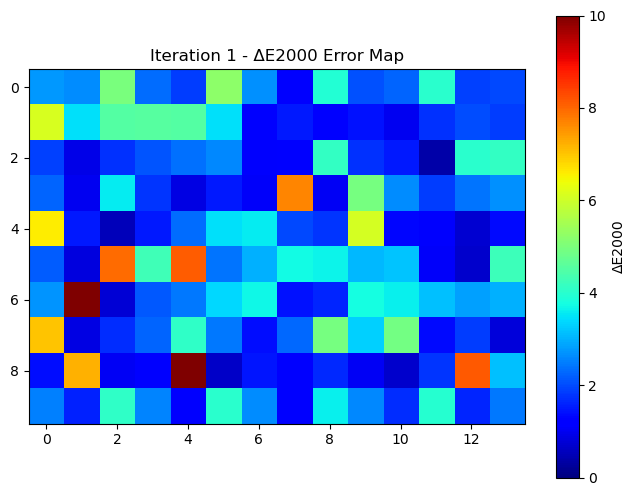

2025-03-28 08:13:20,062 - INFO - Iteration 2
2025-03-28 08:13:20,071 - INFO - Epoch 1/500 - Train Loss: 23.3857 - Val Loss: 0.7475
2025-03-28 08:13:20,078 - INFO - Epoch 2/500 - Train Loss: 13.2775 - Val Loss: 0.3970
2025-03-28 08:13:20,086 - INFO - Epoch 3/500 - Train Loss: 7.2442 - Val Loss: 0.2066
2025-03-28 08:13:20,093 - INFO - Epoch 4/500 - Train Loss: 3.9952 - Val Loss: 0.1134
2025-03-28 08:13:20,101 - INFO - Epoch 5/500 - Train Loss: 2.3763 - Val Loss: 0.0705
2025-03-28 08:13:20,108 - INFO - Epoch 6/500 - Train Loss: 1.4970 - Val Loss: 0.0469
2025-03-28 08:13:20,117 - INFO - Epoch 7/500 - Train Loss: 1.0004 - Val Loss: 0.0347
2025-03-28 08:13:20,125 - INFO - Epoch 8/500 - Train Loss: 0.7062 - Val Loss: 0.0263
2025-03-28 08:13:20,132 - INFO - Epoch 9/500 - Train Loss: 0.5179 - Val Loss: 0.0211
2025-03-28 08:13:20,140 - INFO - Epoch 10/500 - Train Loss: 0.3891 - Val Loss: 0.0180
2025-03-28 08:13:20,147 - INFO - Epoch 11/500 - Train Loss: 0.3109 - Val Loss: 0.0162
2025-03-28 08:13

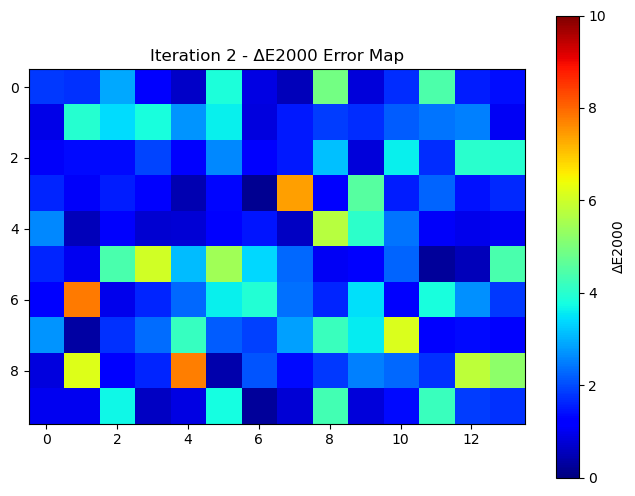

2025-03-28 08:13:20,683 - INFO - Iteration 3
2025-03-28 08:13:20,692 - INFO - Epoch 1/500 - Train Loss: 23.8246 - Val Loss: 0.9427
2025-03-28 08:13:20,699 - INFO - Epoch 2/500 - Train Loss: 17.3120 - Val Loss: 0.6864
2025-03-28 08:13:20,707 - INFO - Epoch 3/500 - Train Loss: 12.5740 - Val Loss: 0.4802
2025-03-28 08:13:20,714 - INFO - Epoch 4/500 - Train Loss: 9.0081 - Val Loss: 0.3485
2025-03-28 08:13:20,722 - INFO - Epoch 5/500 - Train Loss: 6.6556 - Val Loss: 0.2501
2025-03-28 08:13:20,729 - INFO - Epoch 6/500 - Train Loss: 4.9304 - Val Loss: 0.1832
2025-03-28 08:13:20,737 - INFO - Epoch 7/500 - Train Loss: 3.7034 - Val Loss: 0.1386
2025-03-28 08:13:20,745 - INFO - Epoch 8/500 - Train Loss: 2.8368 - Val Loss: 0.1052
2025-03-28 08:13:20,753 - INFO - Epoch 9/500 - Train Loss: 2.1805 - Val Loss: 0.0814
2025-03-28 08:13:20,760 - INFO - Epoch 10/500 - Train Loss: 1.7038 - Val Loss: 0.0633
2025-03-28 08:13:20,768 - INFO - Epoch 11/500 - Train Loss: 1.3211 - Val Loss: 0.0512
2025-03-28 08:1

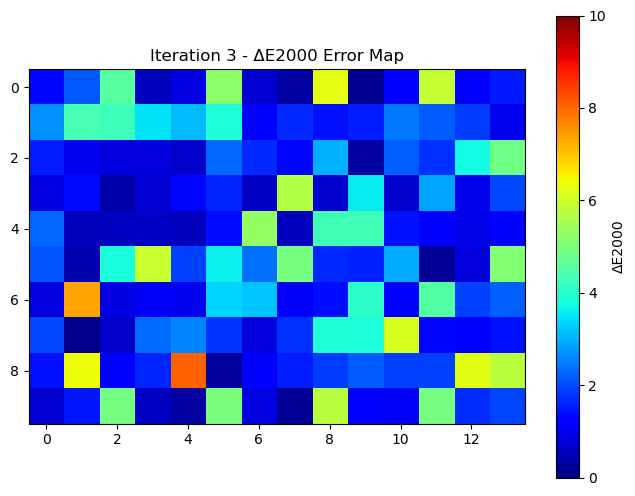

2025-03-28 08:13:21,618 - INFO - Results got worse. Reverting to the best iteration and stopping refinement.
2025-03-28 08:13:21,618 - INFO - Final error evaluation:
2025-03-28 08:13:21,619 - INFO - Final Mean ΔE2000 Error: 3.21
2025-03-28 08:13:21,620 - INFO - Final Max ΔE2000 Error: 7.40


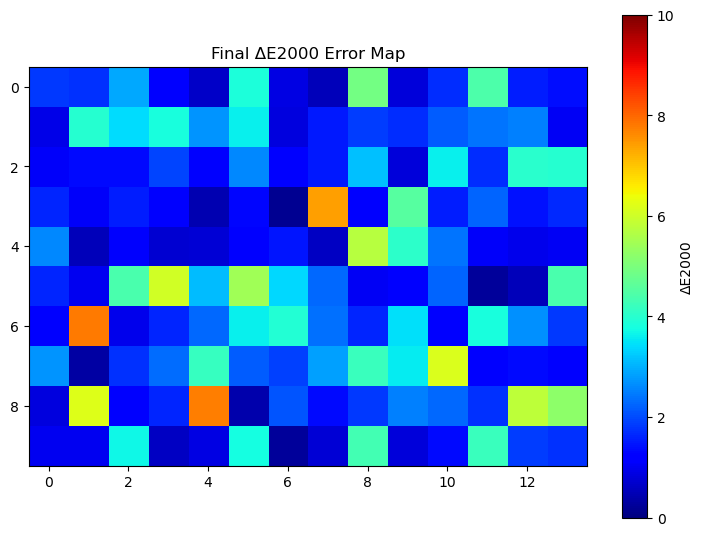

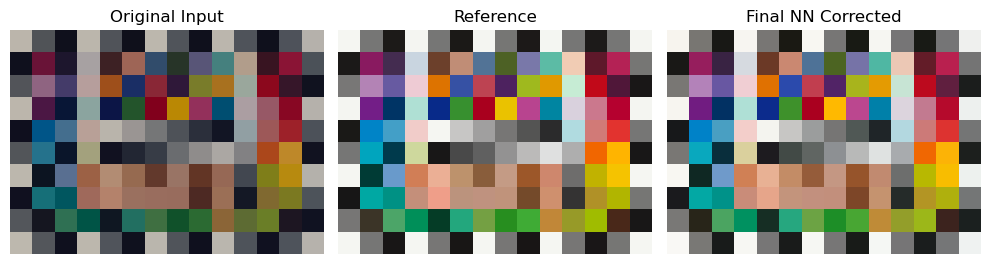

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import StandardScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt
import copy
import os

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a fixed seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions
###########################################
def process_rgb(cube, bands, ill, CMFs):
    """Converts hyperspectral cube data to RGB using XYZ conversion."""
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)
    rgb = color.xyz2rgb(xyz)
    return rgb

###########################################
# Early stopping class (per iteration)
###########################################
class EarlyStopping:
    """Stops training if validation loss doesn't improve after a set patience."""
    def __init__(self, patience=50, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):
        if val_loss + self.min_delta < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0  # Reset patience
        else:
            self.counter += 1  # Increment patience
        return self.counter >= self.patience  # Return True if no improvement

###########################################
# 1. Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube_path = '../../data/colorChecker_SG/cubes/cubeCC_fuji-frame4.hdr'
cube = spectral.open_image(cube_path)
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()         
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref   = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# 2. Process RGB data
###########################################
logging.info('Processing RGB data...')
rgb_input = process_rgb(cube_data, wl_input, ill, CMFs)   
rgb_ref   = process_rgb(cube_ref_data, wl_ref, ill, CMFs)   

H, W, C = rgb_input.shape

###########################################
# 3. Normalize data in RGB space
###########################################
logging.info('Normalizing RGB data...')
# Flatten the images so each pixel is a sample
X_flat = rgb_input.reshape(-1, 3)
Y_flat = rgb_ref.reshape(-1, 3)

scaler_input = StandardScaler()
scaler_ref = StandardScaler()

###########################################
# 4. Define the MLP model
###########################################
class SimpleMLP(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, output_size=3):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

###########################################
# 5. Iterative Training with Early Stopping,
#    Residual Learning (Blending), and stopping
#    when the results get worse.
###########################################
max_iterations = 10  # maximum allowed iterations
epochs = 500         # maximum epochs per iteration
batch_size = 4
alpha = 0.6          # Blending factor for residual learning

best_mean_error = float('inf')
best_X_flat = None    # to store best corrected normalized data
best_scaler_ref = None  # to store the scaler of the best iteration
iteration = 0

while iteration < max_iterations:
    logging.info(f"Iteration {iteration+1}")

    # Dynamically update normalization for current data
    X_norm = scaler_input.fit_transform(X_flat)
    Y_norm = scaler_ref.fit_transform(Y_flat)

    # Convert normalized data to torch tensors
    X_tensor = torch.tensor(X_norm, dtype=torch.float32)
    Y_tensor = torch.tensor(Y_norm, dtype=torch.float32)

    np.random.seed(seed)
    # Split into training (80%) and test (20%) sets
    n_pixels = X_norm.shape[0]
    train_size = int(0.8 * n_pixels)
    train_indices = np.random.choice(n_pixels, train_size, replace=False)
    test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)

    X_train = X_tensor[train_indices]
    Y_train = Y_tensor[train_indices]
    X_test = X_tensor[test_indices]
    Y_test = Y_tensor[test_indices]

    # Initialize model, optimizer, loss function, and early stopping
    model = SimpleMLP()
    optimizer = optim.Adam(model.parameters(), lr=0.001 / (iteration+1), weight_decay=1e-5)
    loss_function = nn.MSELoss()
    early_stopping = EarlyStopping(patience=50, min_delta=1e-5)

    # Training loop with early stopping
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        perm = torch.randperm(X_train.size(0))
        for i in range(0, X_train.size(0), batch_size):
            batch_indices = perm[i:i+batch_size]
            X_batch = X_train[batch_indices]
            Y_batch = Y_train[batch_indices]

            optimizer.zero_grad()
            Y_pred = model(X_batch)
            loss = loss_function(Y_pred, Y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Compute validation loss on test set
        model.eval()
        with torch.no_grad():
            Y_val_pred = model(X_test)
            val_loss = loss_function(Y_val_pred, Y_test).item()
        logging.info(f'Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f} - Val Loss: {val_loss:.4f}')
        if early_stopping(val_loss):
            logging.info(f"Early stopping triggered at epoch {epoch+1}")
            break

    # Apply correction using the current model on the whole normalized X_norm
    model.eval()
    with torch.no_grad():
        corrected_norm = model(torch.tensor(X_norm, dtype=torch.float32)).numpy()

    # Inverse-transform for visualization (optional)
    corrected_rgb = scaler_ref.inverse_transform(corrected_norm)
    corrected_rgb_image = corrected_rgb.reshape(rgb_ref.shape)

    # Compute ΔE2000 error map for the current iteration
    corrected_lab = color.rgb2lab(corrected_rgb_image)
    lab_ref_current = color.rgb2lab(rgb_ref)
    error_map = color.deltaE_ciede2000(lab_ref_current, corrected_lab)

    # Evaluate error on the test indices
    error_map_flat = error_map.reshape(-1)
    current_mean_error = np.mean(error_map_flat[test_indices])
    current_max_error = np.max(error_map_flat[test_indices])
    logging.info(f"Iteration {iteration+1}: Mean ΔE2000 Error: {current_mean_error:.2f}, Max ΔE2000 Error: {current_max_error:.2f}")

    # Plot error map for the current iteration
    plt.figure(figsize=(8,6))
    plt.imshow(error_map, cmap='jet', vmin=0, vmax=10)
    plt.colorbar(label='ΔE2000')
    plt.title(f'Iteration {iteration+1} - ΔE2000 Error Map')
    plt.show()

    # If the current error is lower than the best seen so far, update best results
    if current_mean_error < best_mean_error:
        best_mean_error = current_mean_error
        best_X_flat = X_flat.copy()           # store best corrected normalized data
        # Update X_flat using residual learning with blending:
        X_flat = alpha * corrected_norm + (1 - alpha) * X_flat
        best_corrected_rgb = corrected_rgb_image.copy() 
        iteration += 1
    else:
        logging.info("Results got worse. Reverting to the best iteration and stopping refinement.")
        corrected_rgb_image = best_corrected_rgb
        break

###########################################
# 6. Final Correction and Visual Comparison
###########################################
# Final corrected result: inverse-transform X_flat using the best scaler

logging.info('Final error evaluation:')
corrected_lab = color.rgb2lab(corrected_rgb_image)
lab_ref_final = color.rgb2lab(rgb_ref)
error_map = color.deltaE_ciede2000(lab_ref_final, corrected_lab)
error_map_flat = error_map.reshape(-1)
final_mean_error = np.mean(error_map_flat[test_indices])
final_max_error = np.max(error_map_flat[test_indices])
logging.info(f"Final Mean ΔE2000 Error: {final_mean_error:.2f}")
logging.info(f"Final Max ΔE2000 Error: {final_max_error:.2f}")

# Plot final ΔE2000 error map
plt.figure(figsize=(8, 6))
plt.imshow(error_map, cmap='jet', vmin=0, vmax=10)
plt.colorbar(label='ΔE2000')
plt.title('Final ΔE2000 Error Map')
plt.tight_layout(pad=3.0)
plt.show()

# Final visual comparison: Original, Reference, and Corrected images
plt.figure(figsize=(10, 4))
plt.subplot(1,3,1)
plt.imshow(np.clip(rgb_input, 0, 1))
plt.title('Original Input')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(np.clip(rgb_ref, 0, 1))
plt.title('Reference')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(np.clip(corrected_rgb_image, 0, 1))
plt.title('Final NN Corrected')
plt.axis('off')
plt.tight_layout()
plt.show()
